# 03 · Optimization of the PM interval
Find the PM interval that best trades off annual maintenance cost against probability of failure.
- Input: `data/weibull_params.json` (from notebook 02)
- Output: the Pareto front, the recommended PM plan, the NSGA-II tuning results (`data/tuning_*.csv`) and figures

## Problem formulation
The decision variable is the PM interval $x$ in months, with $1 \le x \le 12$. Both objectives are minimized:

$$
\min\; C(x) = \underbrace{\frac{12}{x}\, C_{PM}\, n}_{\text{preventive}} \;+\; \underbrace{F(x)\, C_{CM}\, n}_{\text{corrective}}
\qquad\qquad
\min\; F(x) = 1 - e^{-(x/\eta)^{\beta}}
$$

- $n$: number of pumps
- $C_{PM}$ = 1: cost of one PM job (costs are in relative units)
- $C_{CM}$ ≈ 125.66: average cost of one corrective job, relative to a PM job
- $F(x)$: probability that a pump fails within one PM interval

Shorter intervals lower the failure risk but add PM jobs, which is the trade-off to optimize. Annual cost is reported as an index, with the current 6-month plan = 100.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pm_optimization as pm

# Same colours and figure style as notebook 02
TEAL, GREY, RED = "#00534d", "#9AA5B1", "#C0392B"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.3})

# Build the cost / failure model from the Weibull fit saved by notebook 02
params = pm.load_params()
model = pm.PMModel.from_params(params)
model

PMModel(beta=1.1465773914889534, eta_months=49.54594188958013, n_pumps=99, pm_cost=1.0, cm_cost=125.6611491829204)

## The current plan and some alternatives
The pumps are currently serviced every 6 months. Both objectives for a few round intervals:

In [2]:
# Whole-month intervals from monthly to yearly, including the current 6 months
intervals = [1, 2, 3, 4, 6, 9, 12]
pd.DataFrame({
    "Annual cost (index)": model.cost_index(intervals).round(1),
    "Failure probability (%)": (model.failure_prob(intervals) * 100).round(2),
}, index=pd.Index(intervals, name="Interval (months)"))

,Annual cost (index),Failure probability (%)
Interval (months),,
1,105.8,1.13
2,72.0,2.49
3,70.5,3.93
4,77.4,5.43
6,100.0,8.50
9,141.2,13.19
12,184.8,17.86


## The exact Pareto front
With only one decision variable, the Pareto front can be found exactly by evaluating a dense grid of intervals. This gives the answer NSGA-II should find in the NSGA-II section below.

In [3]:
# Every interval on a fine grid between 1 and 12 months, keeping the non-dominated ones
x_exact, F_exact = pm.brute_force_front(model)
print(f"Pareto-optimal intervals: {x_exact.min():.2f} to {x_exact.max():.2f} months")

# The same idea restricted to intervals that can be scheduled (half-month steps)
plans = pm.practical_plans(model)
plans[plans["pareto_optimal"]].round(2)

Pareto-optimal intervals: 1.00 to 2.57 months


,interval_months,label,annual_cost_index,failure_prob_pct,reliability_pct,pareto_optimal
0,1.0,1M,105.81,1.13,98.87,True
1,1.5,1M 2W,80.86,1.80,98.20,True
2,2.0,2M,71.97,2.49,97.51,True
3,2.5,2M 2W,69.58,3.20,96.80,True


## Why the front stops at about 2.5 months
Cost is U-shaped: short intervals pay for many PM jobs, long intervals pay for more failures. Failure probability only rises with the interval. So beyond the cheapest interval, every longer plan costs more *and* fails more often, which means it is dominated.

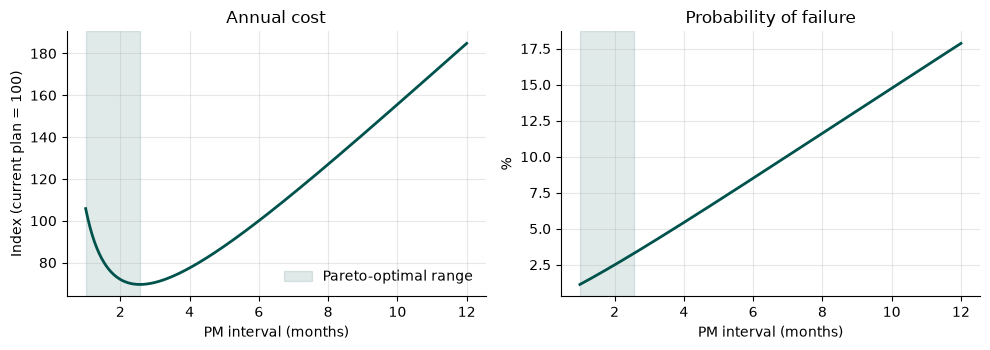

In [4]:
# Both objectives across the full 1 to 12 month range
x = np.linspace(*pm.BOUNDS, 500)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.6))

ax1.plot(x, model.cost_index(x), color=TEAL, lw=2)
# Shade the Pareto-optimal range on both curves
ax1.axvspan(x_exact.min(), x_exact.max(), color=TEAL, alpha=0.12, label="Pareto-optimal range")
ax1.set(title="Annual cost", xlabel="PM interval (months)", ylabel="Index (current plan = 100)")
ax1.legend(frameon=False)

ax2.plot(x, model.failure_prob(x) * 100, color=TEAL, lw=2)
ax2.axvspan(x_exact.min(), x_exact.max(), color=TEAL, alpha=0.12)
ax2.set(title="Probability of failure", xlabel="PM interval (months)", ylabel="%")

fig.tight_layout()
plt.show()

## Recommended plan
The recommended plan is the lowest-cost Pareto-optimal plan.

In [5]:
# Current plan (6 months) and the cheapest plan, which is always on the front
# (both are also used by the Pareto figure below)
current = plans.set_index("interval_months").loc[pm.CURRENT_PM_INTERVAL]
selected = plans.loc[plans["annual_cost_index"].idxmin()]

# Negative change in cost is a saving; positive change in reliability is an improvement
pm.compare_with_current(model).round(2)

,Current (6M),Recommended (2M 2W),Change
"Annual cost (index, current plan = 100)",100.0,69.58,-30.42
Reliability over interval (%),91.5,96.80,5.30


## NSGA-II
NSGA-II (pymoo) is run with these settings: population 400, SBX crossover (probability 0.98, distribution index 20), polynomial mutation (probability 0.01, distribution index 20) and a budget of 50,000 evaluations. Its front is compared with the exact front from the grid search.

In [6]:
# res.X holds the intervals on NSGA-II's front, res.F their [cost, failure probability]
res = pm.run_nsga2(model)
print(f"NSGA-II front: {res.X.min():.3f} to {res.X.max():.3f} months ({len(res.X)} solutions)")
print(f"Exact front:   {x_exact.min():.3f} to {x_exact.max():.3f} months")

NSGA-II front: 1.000 to 2.566 months (400 solutions)
Exact front:   1.000 to 2.566 months


## Hypervolume
Hypervolume is the area of objective space dominated by a front, measured up to a reference point. Higher is better: it rewards fronts that are both close to the optimum and well spread. The reference point is the exact front's worst corner (nadir) plus 10%. Because the exact front is known, each result is also reported as a percentage of the exact front's hypervolume.

In [7]:
# The same reference point is used for every hypervolume in this notebook, so they can be compared
ref = pm.reference_point(model)
hv_exact = pm.hypervolume(F_exact, ref)
hv_nsga = pm.hypervolume(res.F, ref)

print(f"Reference point: cost index {ref[0]:.1f}, failure probability {ref[1]:.4f}")
print(f"Hypervolume, exact front: {hv_exact:.4f}")
print(f"Hypervolume, NSGA-II:     {hv_nsga:.4f} ({hv_nsga / hv_exact:.2%} of exact)")

Reference point: cost index 116.4, failure probability 0.0363
Hypervolume, exact front: 0.9790
Hypervolume, NSGA-II:     0.9781 (99.91% of exact)


## Which NSGA-II settings matter?
Each setting is tested at two levels, with 5 independent runs per level and a fixed budget of 50,000 evaluations. A two-sample t-test checks whether the setting changes the hypervolume.

Set `RUN_TUNING = True` to re-run the experiments (about 5 minutes); otherwise the saved results in `data/tuning_significance.csv` are loaded.

In [8]:
RUN_TUNING = False
path = pm.DATA_DIR / "tuning_significance.csv"

# Low and high level for each setting; all other settings stay at run_nsga2's defaults
experiments = {
    "pop_size": [40, 1000],
    "p_mutate": [0.01, 0.05],
    "p_crossover": [0.8, 0.98],
    "eta_c": [1, 20],
    "eta_m": [1, 20],
}

# Re-run only when asked (or when there is no saved file yet)
if RUN_TUNING or not path.exists():
    runs = pd.concat([pm.tuning_runs(model, s, v) for s, v in experiments.items()], ignore_index=True)
    runs.to_csv(path, index=False, lineterminator="\n")
else:
    runs = pd.read_csv(path)
print(len(runs), "runs")

50 runs


In [9]:
from scipy import stats

# One row per setting: mean hypervolume at each level and the t-test p-value
rows = []
for setting, group in runs.groupby("setting", sort=False):
    # Split the runs by level (groupby sorts the values, so the low level comes first)
    (low, hv_low), (high, hv_high) = group.groupby("value")["hypervolume"]
    rows.append({
        "Setting": setting,
        "Levels": f"{low:g} vs {high:g}",
        "HV low (% of exact)": hv_low.mean() / hv_exact * 100,
        "HV high (% of exact)": hv_high.mean() / hv_exact * 100,
        "Difference (pp)": (hv_high.mean() - hv_low.mean()) / hv_exact * 100,
        "p-value": stats.ttest_ind(hv_low, hv_high).pvalue,
    })
significance = pd.DataFrame(rows).set_index("Setting")
significance["Significant (p < 0.05)"] = significance["p-value"] < 0.05
significance.round(4)

,Levels,HV low (% of exact),HV high (% of exact),Difference (pp),p-value,Significant (p < 0.05)
Setting,,,,,,
pop_size,40 vs 1000,98.9459,99.9712,1.0253,0.0000,True
p_mutate,0.01 vs 0.05,99.9104,99.9058,-0.0046,0.0024,True
p_crossover,0.8 vs 0.98,99.9082,99.9104,0.0022,0.0618,False
eta_c,1 vs 20,99.9095,99.9104,0.0009,0.3732,False
eta_m,1 vs 20,99.9063,99.9104,0.0040,0.0396,True


Population size is the only setting with a practically meaningful effect (about 1 percentage point of hypervolume). Mutation probability and η_m pass p < 0.05, but their effects are below 0.01 percentage points: runs are so consistent that tiny differences become statistically detectable without mattering in practice. With five tests, a stricter threshold (Bonferroni, p < 0.01) also removes η_m.

## Choosing the population size
NSGA-II is run once for each population size from 40 to 1,000 (steps of 40), with the same budget of 50,000 evaluations. The results are cached in `data/tuning_population.csv`.

In [10]:
path = pm.DATA_DIR / "tuning_population.csv"
if RUN_TUNING or not path.exists():
    sweep = pm.population_sweep(model, pop_sizes=range(40, 1001, 40))
    sweep.to_csv(path, index=False, lineterminator="\n")
else:
    sweep = pd.read_csv(path)
# Express hypervolume as a percentage of the exact front's
sweep["hv_pct"] = sweep["hypervolume"] / hv_exact * 100

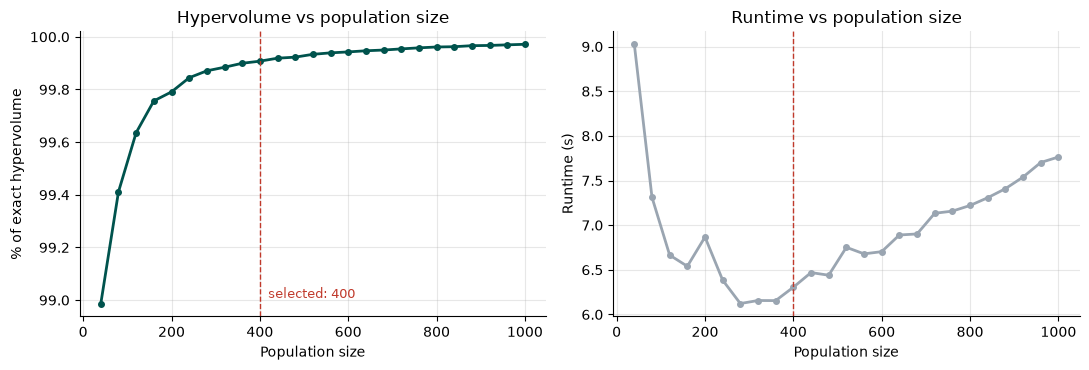

          hv_pct  runtime_s
pop_size                   
40        98.987      9.025
200       99.791      6.867
400       99.908      6.305
1000      99.972      7.763


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))

ax1.plot(sweep["pop_size"], sweep["hv_pct"], marker="o", ms=4, color=TEAL, lw=2)
ax1.set(title="Hypervolume vs population size", xlabel="Population size", ylabel="% of exact hypervolume")

ax2.plot(sweep["pop_size"], sweep["runtime_s"], marker="o", ms=4, color=GREY, lw=2)
ax2.set(title="Runtime vs population size", xlabel="Population size", ylabel="Runtime (s)")

# Mark the population size used for the final run
for ax in (ax1, ax2):
    ax.axvline(400, color=RED, lw=1, ls="--")
ax1.annotate("selected: 400", (400, sweep["hv_pct"].min()), xytext=(6, 4),
             textcoords="offset points", color=RED, fontsize=9)

fig.tight_layout()
fig.savefig(pm.FIG_DIR / "hypervolume_vs_population.png", dpi=200)
plt.show()

# A few sizes side by side
print(sweep.set_index("pop_size").loc[[40, 200, 400, 1000], ["hv_pct", "runtime_s"]].round(3))

Hypervolume rises steeply up to about 250 and then levels off: 400 reaches 99.91% of the exact hypervolume, and 1,000 adds only 0.06 percentage points more. Runtime is U-shaped: small populations need many generations (each with fixed overhead) under the fixed budget, while large populations make non-dominated sorting more expensive. A population of 400 sits at the start of the plateau and near the runtime minimum, so it is used for the final run.

## Results
NSGA-II's front (teal band) against the schedulable half-month plans. Plans beyond the cost minimum are dominated: some shorter interval is both cheaper and safer. The current 6-month plan is one of them.

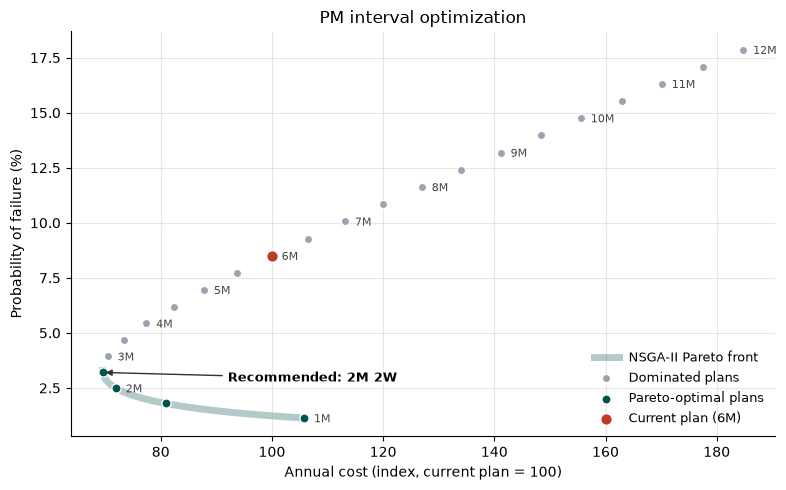

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))

# NSGA-II front, sorted by cost so it draws as one continuous band
order = np.argsort(res.F[:, 0])
ax.plot(res.F[order, 0], res.F[order, 1] * 100, color=TEAL, lw=5, alpha=0.3,
        label="NSGA-II Pareto front", zorder=1)

# Half-month plans: Pareto-optimal vs dominated
dominated = plans[~plans["pareto_optimal"]]
optimal = plans[plans["pareto_optimal"]]
ax.scatter(dominated["annual_cost_index"], dominated["failure_prob_pct"], s=36, color=GREY,
           edgecolor="white", label="Dominated plans", zorder=2)
ax.scatter(optimal["annual_cost_index"], optimal["failure_prob_pct"], s=44, color=TEAL,
           edgecolor="white", label="Pareto-optimal plans", zorder=3)
ax.scatter(current["annual_cost_index"], current["failure_prob_pct"], s=70, color=RED,
           edgecolor="white", label="Current plan (6M)", zorder=4)

# Label whole-month plans only, to avoid clutter
for _, p in plans[plans["interval_months"] % 1 == 0].iterrows():
    ax.annotate(p["label"], (p["annual_cost_index"], p["failure_prob_pct"]),
                xytext=(7, -3), textcoords="offset points", fontsize=8, color="#444")

# Arrow to the recommended plan
ax.annotate(f"Recommended: {selected['label']}",
            (selected["annual_cost_index"], selected["failure_prob_pct"]),
            xytext=(90, -4), textcoords="offset points", fontsize=9, fontweight="bold", va="center",
            arrowprops=dict(arrowstyle="-|>", color="#333", lw=1))

ax.set(xlabel="Annual cost (index, current plan = 100)", ylabel="Probability of failure (%)",
       title="PM interval optimization")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.legend(frameon=False, fontsize=9, loc="lower right")

fig.tight_layout()
fig.savefig(pm.FIG_DIR / "pareto_front.png", dpi=200)
plt.show()